# QC Dataset Review

This notebook is a **general-purpose review notebook** for spike-sorting QC datasets.

The goal is to answer the basic questions a developer or neuroscientist should ask
before training any model:

- What is inside the training parquet?
- If a separate test parquet exists, what does it look like?
- If there is no external test parquet yet, what does a grouped preview split look like?
- Are the targets populated and sensible?
- Are waveform, cosine, ACG, and SI feature blocks populated and varied?
- Are there duplicates or obvious leakage warnings that should be addressed first?

## How To Use

1. Review the auto-detected parquet paths in the first code cell.
2. Replace them if needed.
3. Run the notebook top to bottom.

If no external test parquet is provided, the notebook automatically creates a
**preview grouped holdout** by splitting complete recordings. That preview split is
meant for inspection only, not for final performance claims.

In [23]:
import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from qc_framework import QCDataCleaner
from qc_framework.data import QCDataLoader, QCDataSplitter
from qc_framework.pipeline import QCDatasetReviewPipeline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130

# -----------------------------------------------------------------------
# CONFIG — set your paths here
# -----------------------------------------------------------------------
TRAIN_PARQUET_PATH = PROJECT_ROOT / "data" / "featuretrain.parquet"
TEST_PARQUET_PATH  = None  # set to a Path or leave None

# Optional: override the output directory
OUTPUT_DIR = None
# -----------------------------------------------------------------------

assert TRAIN_PARQUET_PATH.exists(), f"Missing training parquet: {TRAIN_PARQUET_PATH}"
if TEST_PARQUET_PATH is not None:
    assert Path(TEST_PARQUET_PATH).exists(), f"Missing test parquet: {TEST_PARQUET_PATH}"

if OUTPUT_DIR is None:
    OUTPUT_DIR = PROJECT_ROOT / "analysis" / "runs" / TRAIN_PARQUET_PATH.stem.lower() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = TRAIN_PARQUET_PATH.stem.lower()

print("Train :", TRAIN_PARQUET_PATH)
print("Test  :", TEST_PARQUET_PATH)
print("Output:", OUTPUT_DIR)

Train : /Users/paulruiz/Documents/Predicting_Good_Units/data/featuretrain.parquet
Test  : None
Output: /Users/paulruiz/Documents/Predicting_Good_Units/analysis/runs/featuretrain/outputs


## 1. Load the Raw Datasets

In [24]:
review = QCDatasetReviewPipeline(TRAIN_PARQUET_PATH, TEST_PARQUET_PATH)
train_df, test_df = review.load()

TARGETS = [c for c in ["accuracy", "fpos", "fmiss", "agreement_score", "precision", "recall"]
           if c in train_df.columns]

# Preview split if no external test
if test_df is not None:
    preview_train_df = train_df.copy()
    preview_test_df = test_df.copy()
    preview_mode = "external_test"
else:
    splitter = QCDataSplitter(test_size=0.2, random_state=42)
    preview_train_df, preview_test_df = splitter.grouped_split(train_df)
    preview_mode = "grouped_preview_from_train"

print("Preview mode:", preview_mode)
display(review.summarize(train_df, "train_raw"))
display(review.summarize(preview_test_df, "test_view"))


Preview mode: grouped_preview_from_train


,dataset,rows,columns,recordings,sorters,duplicate_row_uid
0,train_raw,33206,198,91,9,0


,dataset,rows,columns,recordings,sorters,duplicate_row_uid
0,test_view,8261,198,19,9,0


## 2. First Look at the Training Dataset

In [25]:
display(train_df.head().T)
display(train_df.dtypes.astype(str).rename("dtype").to_frame().head(40))
display(train_df.isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame().head(25))
display(review.target_summary(train_df, TARGETS))

if "dataset_type" in train_df.columns:
    display(train_df["dataset_type"].value_counts().rename("rows").to_frame())
if "study_set" in train_df.columns:
    display(train_df["study_set"].value_counts().rename("rows").to_frame().head(20))
if "sorter_name" in train_df.columns:
    display(train_df["sorter_name"].value_counts().rename("rows").to_frame())


,0,1,2,3,4
study_set,HYBRID_JANELIA,HYBRID_JANELIA,HYBRID_JANELIA,HYBRID_JANELIA,HYBRID_JANELIA
study_name,hybrid_drift_siprobe,hybrid_drift_siprobe,hybrid_drift_siprobe,hybrid_drift_siprobe,hybrid_drift_siprobe
recording_name,rec_16c_1200s_11,rec_16c_1200s_11,rec_16c_1200s_11,rec_16c_1200s_11,rec_16c_1200s_11
sorter_name,HerdingSpikes2,HerdingSpikes2,HerdingSpikes2,HerdingSpikes2,HerdingSpikes2
unit_id,0,1,10,11,12
group_key,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...
row_uid,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...
fmiss,0.080656,0.033054,0.665656,0.589922,0.563956
fpos,0.526775,0.164324,0.186304,0.062461,0.500247
accuracy,0.454361,0.812467,0.310569,0.399172,0.303551


,dtype
study_set,object
study_name,object
recording_name,object
sorter_name,object
unit_id,object
group_key,object
row_uid,object
fmiss,float64
fpos,float64
accuracy,float64


,missing_fraction
hungarian_gt_unit_id,0.678492
gt_key,0.438053
fn,0.438053
precision,0.438053
fmiss,0.438053
recall,0.438053
num_gt,0.438053
matched_gt_unit_id,0.438053
si_amplitude_cv_range,0.407788
si_amplitude_cv_median,0.407788


,target,rows,missing_fraction,mean,std,q05,q50,q95
0,accuracy,33206,0.000000,0.353029,0.385917,0.000000,0.227556,0.996605
1,fpos,33206,0.000000,0.473964,0.476656,0.000000,0.204104,1.000000
2,fmiss,18660,0.438053,0.344678,0.303272,0.001259,0.379517,0.833454
3,agreement_score,33206,0.000000,0.353029,0.385917,0.000000,0.227556,0.996605
4,precision,18660,0.438053,0.936096,0.142984,0.590846,0.994542,1.000000
5,recall,18660,0.438053,0.655322,0.303272,0.166546,0.620483,0.998741


,rows
dataset_type,
hybrid,24224
paired,8982


,rows
study_set,
HYBRID_JANELIA,24224
PAIRED_ENGLISH,3151
PAIRED_MEA64C_YGER,2997
PAIRED_KAMPFF,1743
PAIRED_BOYDEN,907
PAIRED_CRCNS_HC1,184


,rows
sorter_name,
MountainSort4,8594
HerdingSpikes2,5025
JRClust,3914
KiloSort2,3681
SpykingCircus,3598
KiloSort,3166
IronClust,2719
Tridesclous,2379
Klusta,130


## 3. First Look at the Test Dataset or Preview Holdout

In [26]:
preview_targets = [c for c in TARGETS if c in preview_test_df.columns]
display(preview_test_df.head())
display(preview_test_df.dtypes.astype(str).rename("dtype").to_frame().head(40))
display(preview_test_df.isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame().head(25))
display(review.target_summary(preview_test_df, preview_targets))

if "dataset_type" in preview_test_df.columns:
    display(preview_test_df["dataset_type"].value_counts().rename("rows").to_frame())
if "sorter_name" in preview_test_df.columns:
    display(preview_test_df["sorter_name"].value_counts().rename("rows").to_frame())


,study_set,study_name,recording_name,sorter_name,unit_id,group_key,row_uid,fmiss,fpos,accuracy,...,mean_waveform_cosine_top3,median_waveform_cosine,std_waveform_cosine,n_waveform_confusable,min_neighbor_dist_um,mean_neighbor_dist_um,dataset_type,recording_key,sorter_recording_key,gt_key
0,HYBRID_JANELIA,hybrid_drift_siprobe,rec_16c_1200s_11,HerdingSpikes2,0,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,0.080656,0.526775,0.454361,...,0.970391,0.896929,0.463586,27,25.612497,94.860070,hybrid,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...
1,HYBRID_JANELIA,hybrid_drift_siprobe,rec_16c_1200s_11,HerdingSpikes2,1,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,0.033054,0.164324,0.812467,...,0.992856,0.774022,0.389697,21,0.000000,63.094448,hybrid,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...
2,HYBRID_JANELIA,hybrid_drift_siprobe,rec_16c_1200s_11,HerdingSpikes2,10,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,0.665656,0.186304,0.310569,...,0.979804,0.777837,0.529642,23,0.000000,56.049478,hybrid,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...
3,HYBRID_JANELIA,hybrid_drift_siprobe,rec_16c_1200s_11,HerdingSpikes2,11,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,0.589922,0.062461,0.399172,...,0.953263,0.839768,0.419690,27,0.000000,37.593072,hybrid,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...
4,HYBRID_JANELIA,hybrid_drift_siprobe,rec_16c_1200s_11,HerdingSpikes2,12,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,0.563956,0.500247,0.303551,...,0.978794,0.843464,0.523727,27,24.413111,42.657085,hybrid,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...,HYBRID_JANELIA::hybrid_drift_siprobe::rec_16c_...


,dtype
study_set,object
study_name,object
recording_name,object
sorter_name,object
unit_id,object
group_key,object
row_uid,object
fmiss,float64
fpos,float64
accuracy,float64


,missing_fraction
hungarian_gt_unit_id,0.682000
gt_key,0.434935
fn,0.434935
precision,0.434935
fmiss,0.434935
recall,0.434935
matched_gt_unit_id,0.434935
num_gt,0.434935
si_amplitude_cv_median,0.413388
si_amplitude_cv_range,0.413388


,target,rows,missing_fraction,mean,std,q05,q50,q95
0,accuracy,8261,0.000000,0.352451,0.385275,0.000000,0.228277,0.996846
1,fpos,8261,0.000000,0.471524,0.476472,0.000000,0.198613,1.000000
2,fmiss,4668,0.434935,0.349539,0.304488,0.001243,0.386333,0.835304
3,agreement_score,8261,0.000000,0.352451,0.385275,0.000000,0.228277,0.996846
4,precision,4668,0.434935,0.935249,0.145918,0.574746,0.995168,1.000000
5,recall,4668,0.434935,0.650461,0.304488,0.164696,0.613667,0.998757


,rows
dataset_type,
hybrid,6164
paired,2097


,rows
sorter_name,
MountainSort4,2117
HerdingSpikes2,1251
JRClust,974
KiloSort2,971
SpykingCircus,870
KiloSort,798
IronClust,660
Tridesclous,613
Klusta,7


## 4. Train versus Test Comparison

,dataset,rows,columns,recordings,sorters,duplicate_row_uid
0,train_view,24945,198,72,9,0
1,test_view,8261,198,19,9,0


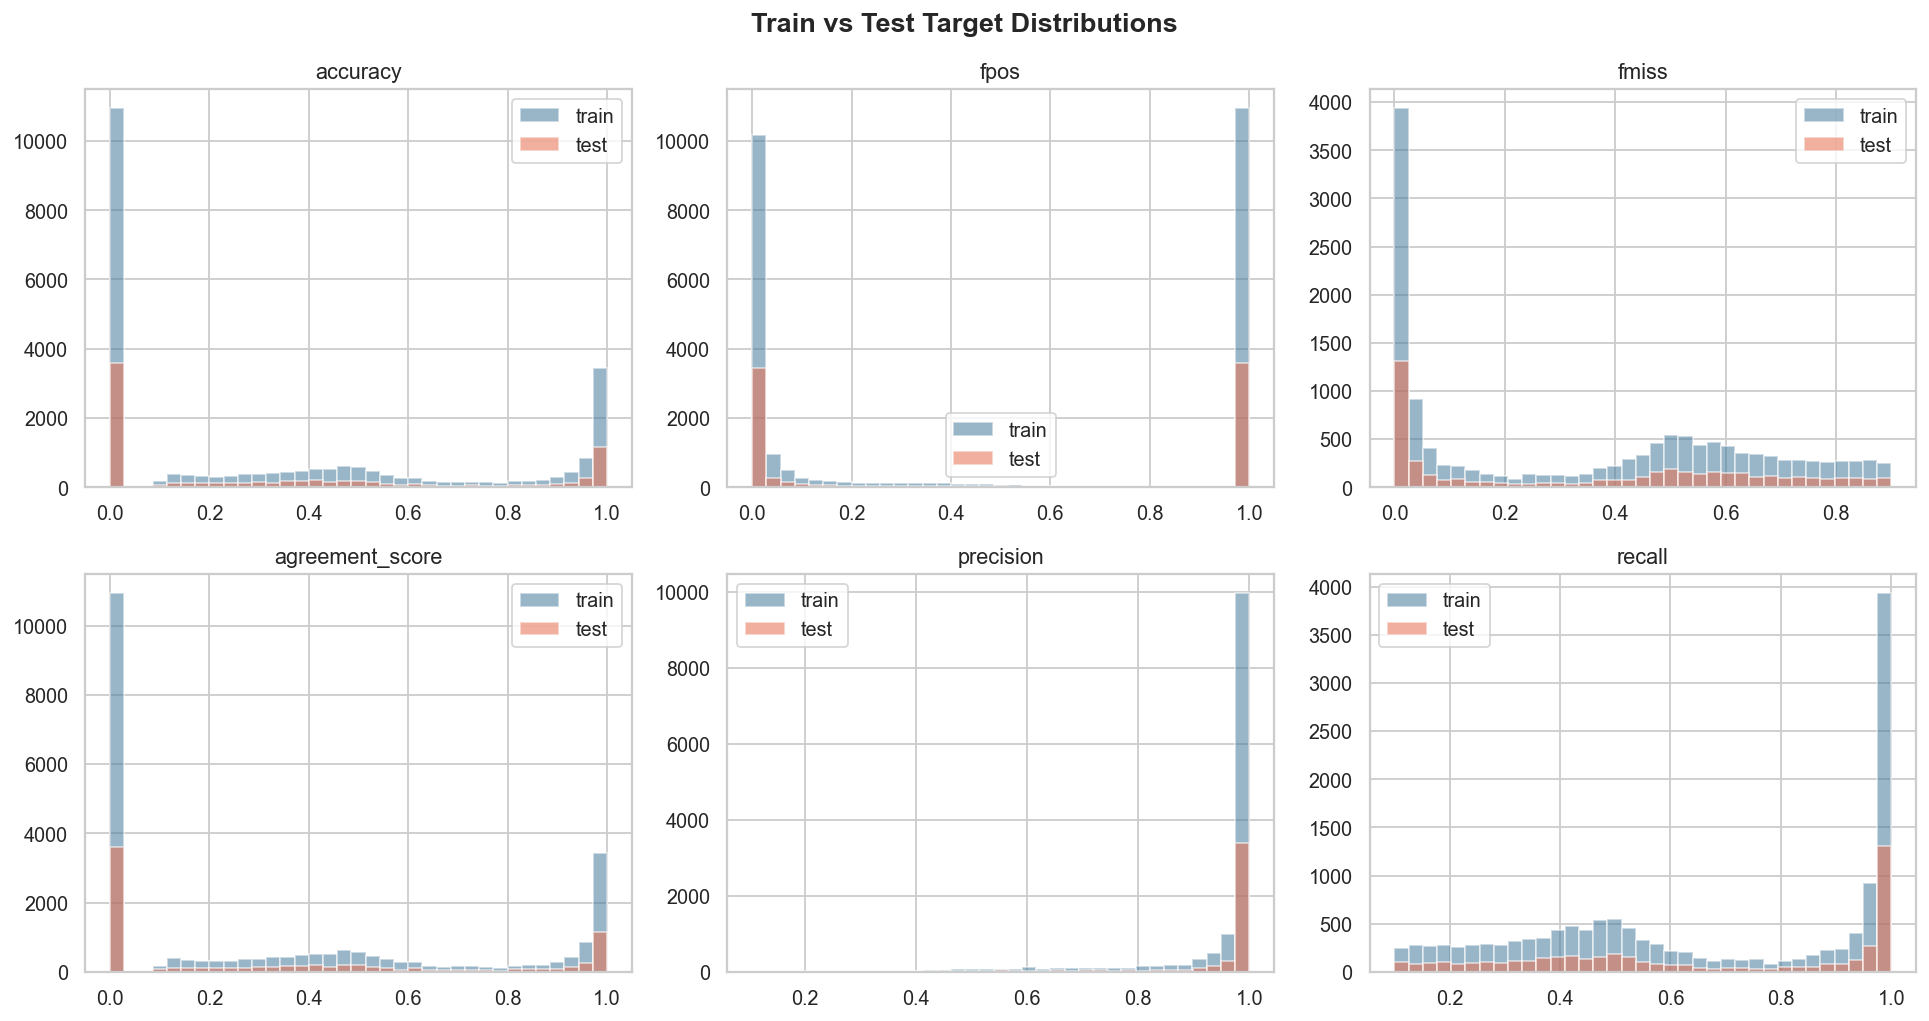

,train_rows,test_rows
dataset_type,,
hybrid,18060,6164
paired,6885,2097


In [27]:
split_summary = pd.concat([
    review.summarize(preview_train_df, "train_view"),
    review.summarize(preview_test_df, "test_view"),
], ignore_index=True)
display(split_summary)

compare_targets = [c for c in TARGETS if c in preview_train_df.columns and c in preview_test_df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = np.array(axes).reshape(-1)
for ax, target in zip(axes, compare_targets[:6]):
    train_vals = pd.to_numeric(preview_train_df[target], errors="coerce").dropna().to_numpy()
    test_vals = pd.to_numeric(preview_test_df[target], errors="coerce").dropna().to_numpy()
    ax.hist(train_vals, bins=35, alpha=0.55, label="train", color="#457b9d", edgecolor="white")
    ax.hist(test_vals, bins=35, alpha=0.55, label="test", color="#e76f51", edgecolor="white")
    ax.set_title(target)
    ax.legend()
for ax in axes[len(compare_targets[:6]):]:
    ax.axis("off")
fig.suptitle("Train vs Test Target Distributions", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

if "dataset_type" in preview_train_df.columns:
    coverage = pd.concat([
        preview_train_df["dataset_type"].value_counts().rename("train_rows"),
        preview_test_df["dataset_type"].value_counts().rename("test_rows"),
    ], axis=1).fillna(0).astype(int)
    display(coverage)


## 5. Integrity Checks and Leakage Warnings

In [28]:
print("Train integrity")
display(review.integrity_report(train_df))

print("Test / preview integrity")
display(review.integrity_report(preview_test_df))

# Exact duplicate numeric columns
from qc_framework.features import FeatureSetBuilder
dup_pairs = FeatureSetBuilder.find_exact_duplicate_pairs(train_df)
display(pd.DataFrame(dup_pairs, columns=["exact_duplicate_a", "exact_duplicate_b"]))

# Dataset-type leakage scan
cleaner = QCDataCleaner()
leakage_scan = cleaner.dataset_type_leakage_scan(train_df)
print("Dataset-type leakage scan (rec_* features):")
display(leakage_scan)


Train integrity


,rows,duplicate_row_uid,duplicate_recording_sorter_unit,matched_gt_keys_total,matched_gt_keys_multi_row,matched_gt_keys_multi_sorter,max_sorters_per_gt_key,perfect_accuracy_gt_multi_sorter
0,33206,0,0,1924,1887,1883,9,11


Test / preview integrity


,rows,duplicate_row_uid,duplicate_recording_sorter_unit,matched_gt_keys_total,matched_gt_keys_multi_row,matched_gt_keys_multi_sorter,max_sorters_per_gt_key,perfect_accuracy_gt_multi_sorter
0,8261,0,0,479,470,470,8,3


,exact_duplicate_a,exact_duplicate_b
0,accuracy,agreement_score
1,num_tested,spike_count
2,snr,wf_ptp_ratio
3,n_channels,rec_n_channels


Dataset-type leakage scan (rec_* features):


,feature,stat,p_value,effect_size,action
1,rec_noise_std_uv,20193.004,0.000000e+00,0.6081,flag
0,rec_noise_mean_uv,20187.934,0.000000e+00,0.6080,flag
5,rec_sampling_rate,9487.613,0.000000e+00,0.2857,flag
2,rec_duration_sec,5365.065,0.000000e+00,0.1615,flag
3,rec_n_channels,1419.320,1.330739e-310,0.0427,flag
4,rec_n_units,71.457,2.833677e-17,0.0021,flag


## 6. Feature Family Coverage

,family,n_columns
0,waveform,59
2,acg,40
1,waveform_bins,30
4,spikeinterface,15
3,cosine,14
5,recording,6


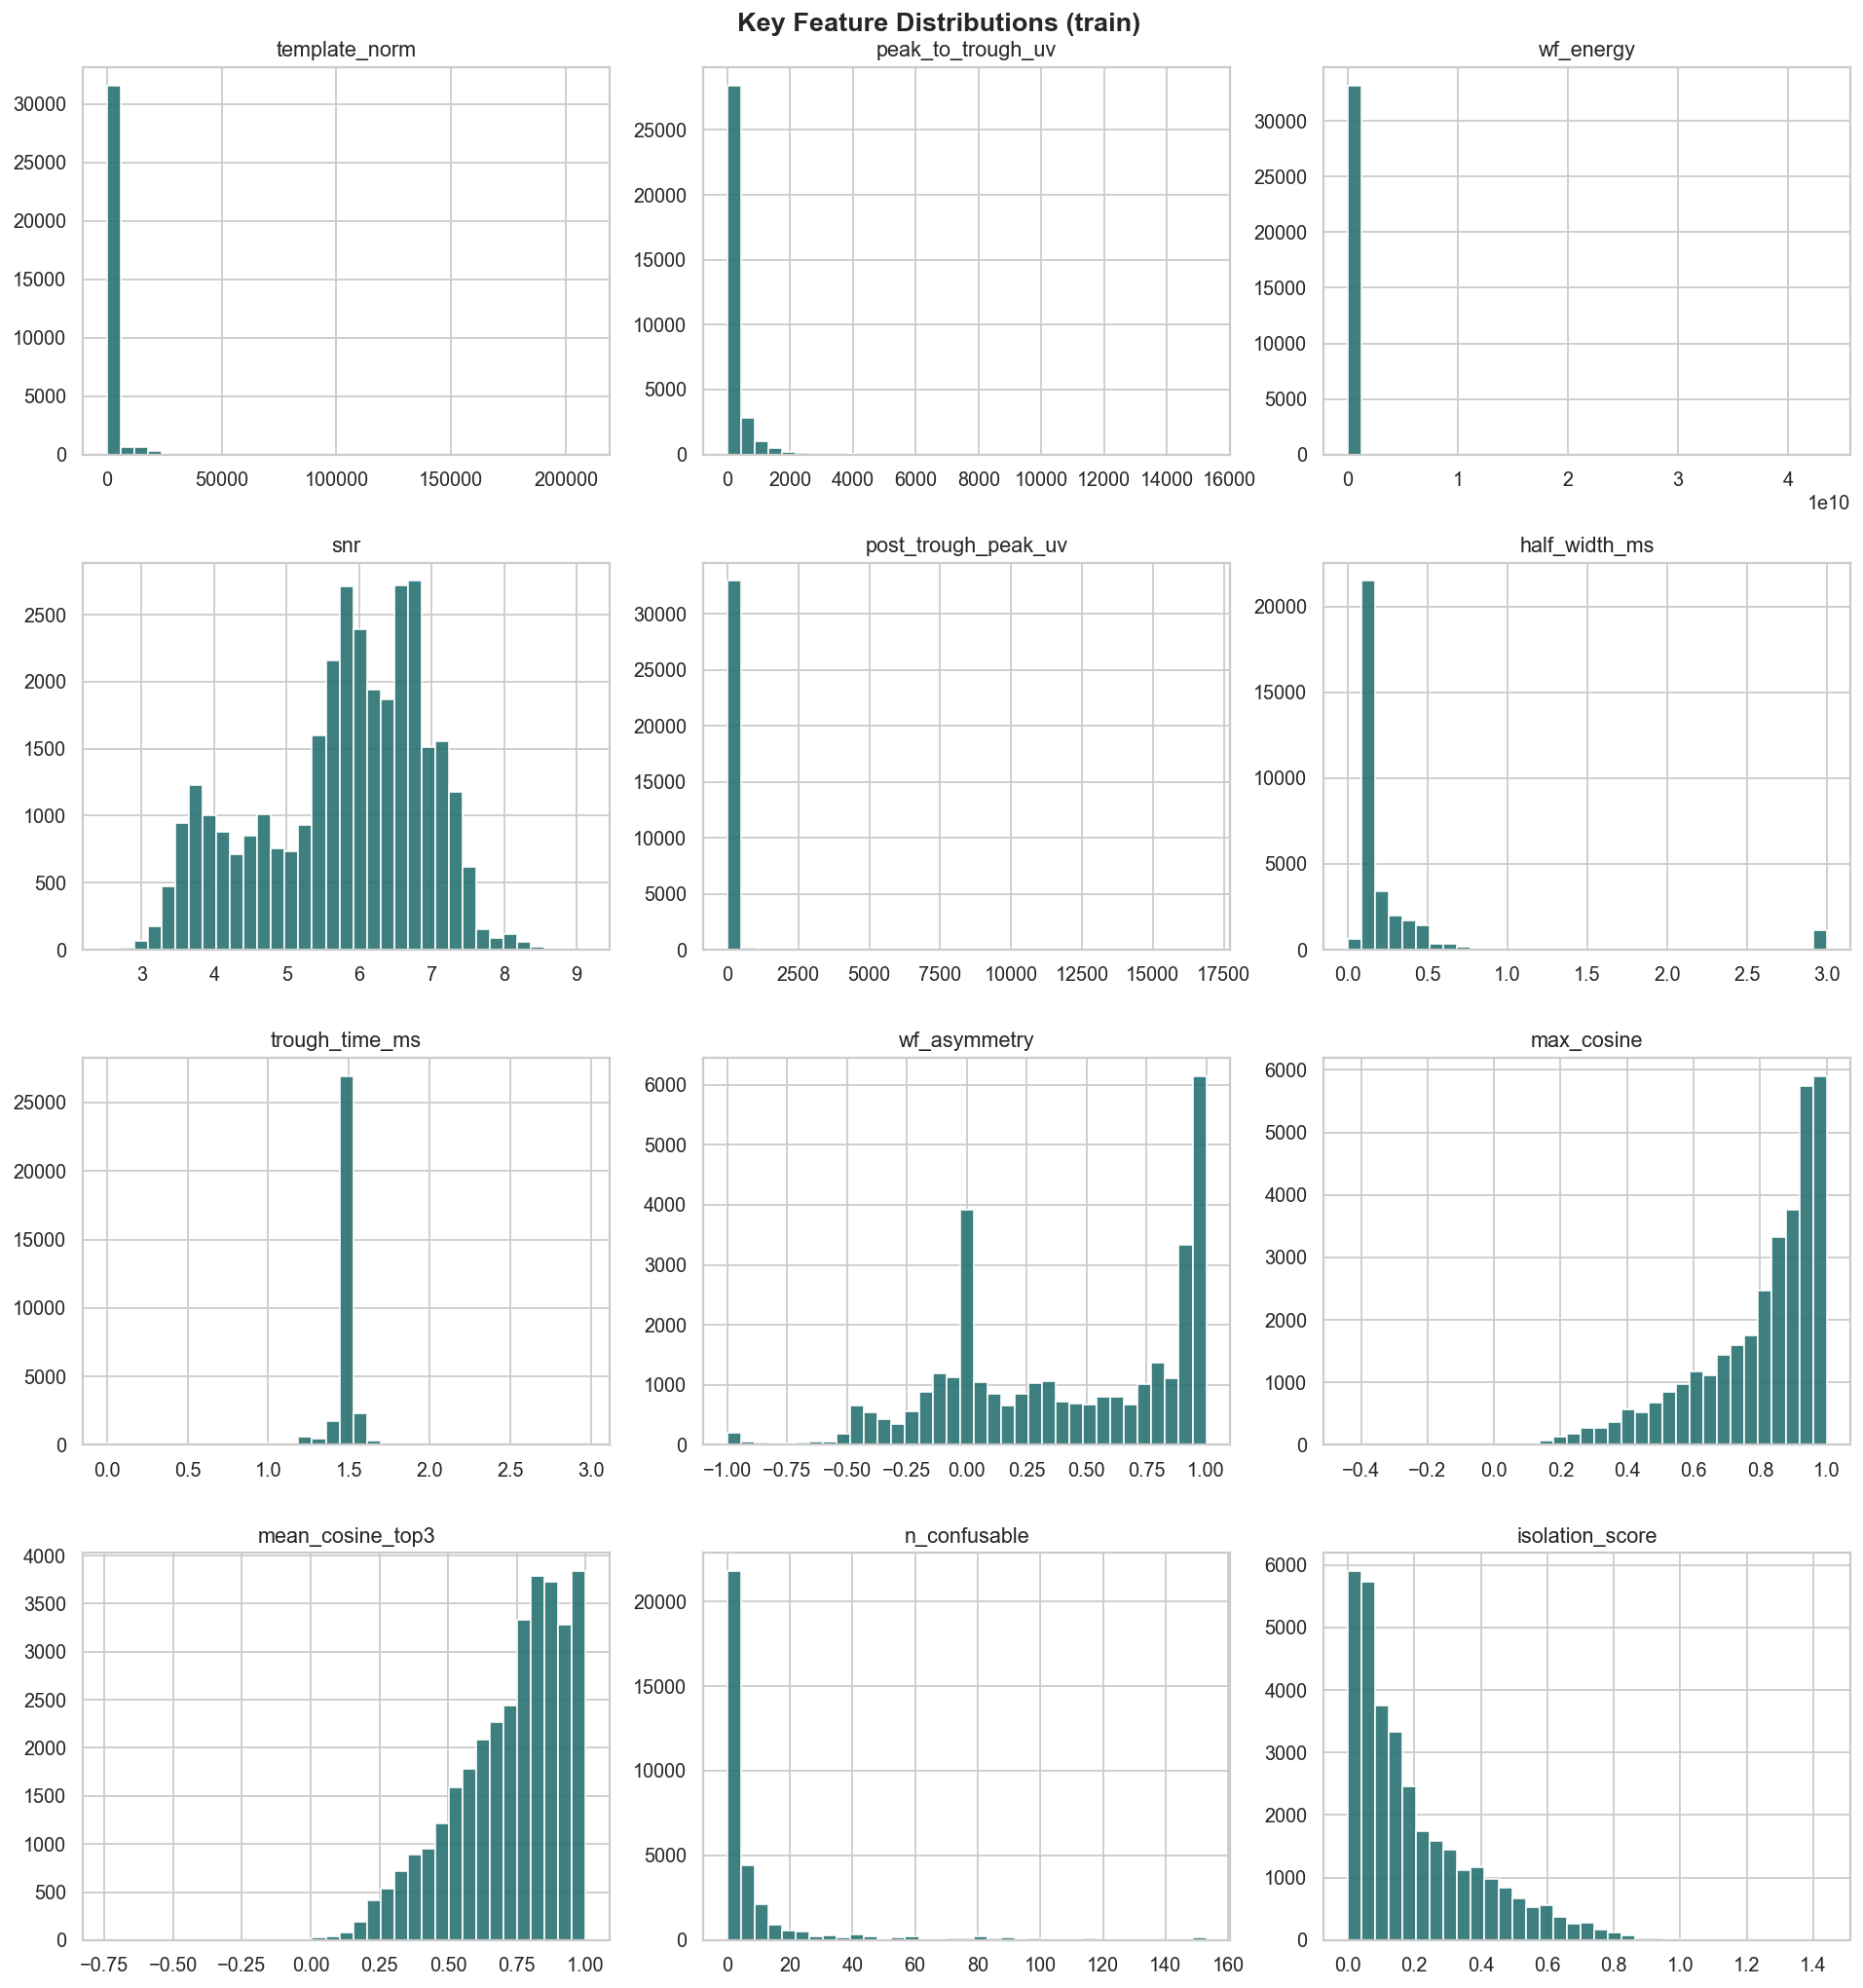

In [29]:
families = review.detect_feature_families(train_df)

family_counts = pd.DataFrame([
    {"family": family, "n_columns": len(cols)}
    for family, cols in families.items()
]).sort_values("n_columns", ascending=False)
display(family_counts)

key_cols = []
key_cols += [c for c in ["template_norm", "peak_to_trough_uv", "wf_energy", "snr",
                          "post_trough_peak_uv", "half_width_ms", "trough_time_ms",
                          "wf_asymmetry"] if c in train_df.columns]
key_cols += [c for c in ["max_cosine", "mean_cosine_top3", "n_confusable",
                          "isolation_score"] if c in train_df.columns]
key_cols = list(dict.fromkeys(key_cols))[:12]

if key_cols:
    ncols = 3
    nrows = math.ceil(len(key_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, key_cols):
        vals = pd.to_numeric(train_df[col], errors="coerce").dropna().to_numpy()
        ax.hist(vals, bins=35, color="#287271", alpha=0.9, edgecolor="white")
        ax.set_title(col)
    for ax in axes[len(key_cols):]:
        ax.axis("off")
    fig.suptitle("Key Feature Distributions (train)", fontsize=15, fontweight="bold")
    fig.tight_layout()
    plt.show()


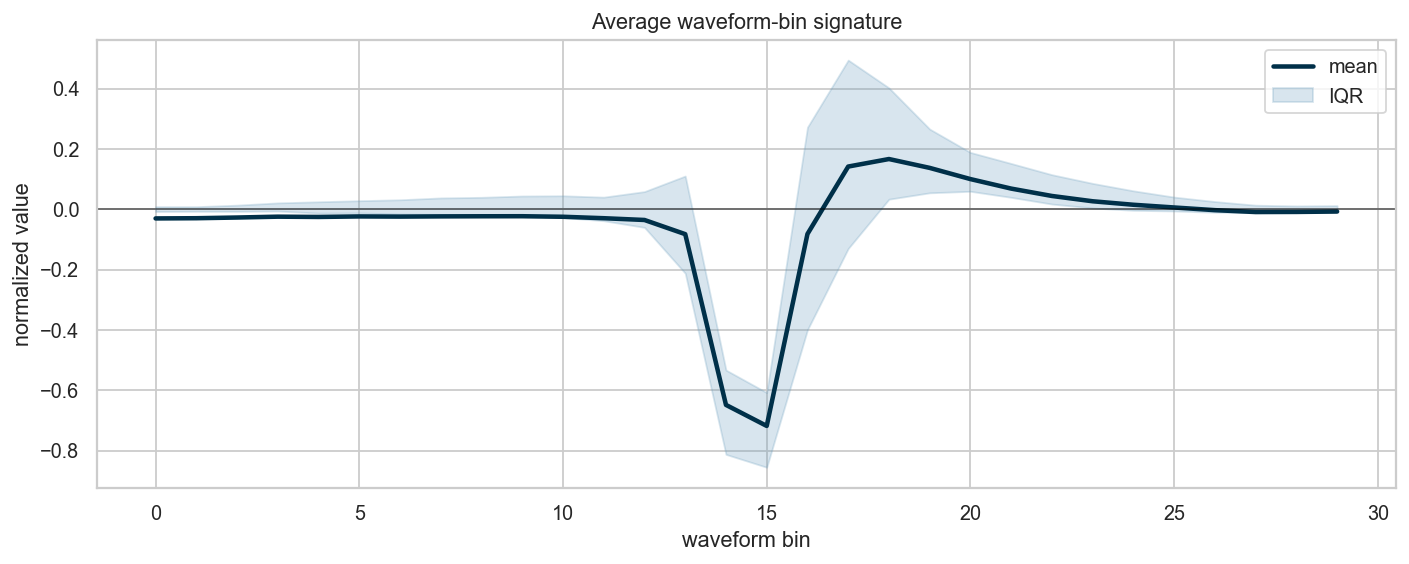

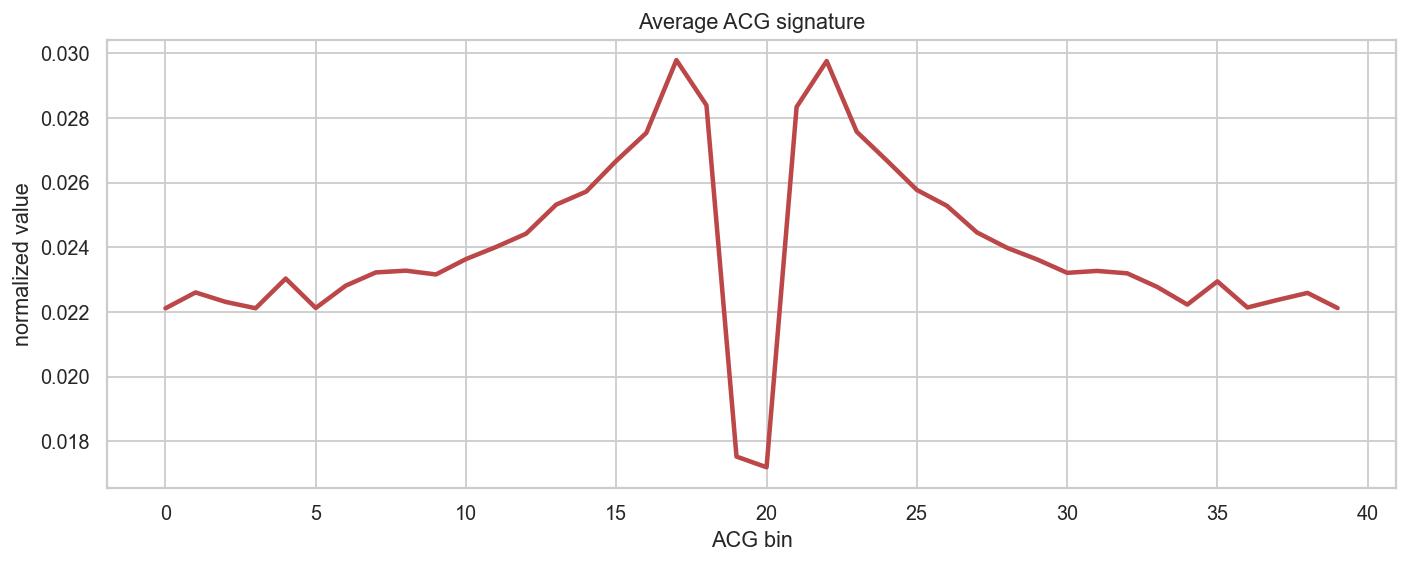

In [30]:
if families["waveform_bins"]:
    wf_mat = train_df[families["waveform_bins"]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(wf_mat):
        x = np.arange(len(families["waveform_bins"]))
        mean_wave = wf_mat.mean(axis=0).to_numpy()
        q25 = wf_mat.quantile(0.25, axis=0).to_numpy()
        q75 = wf_mat.quantile(0.75, axis=0).to_numpy()
        fig, ax = plt.subplots(figsize=(11, 4.5))
        ax.plot(x, mean_wave, color="#003049", lw=2.5, label="mean")
        ax.fill_between(x, q25, q75, color="#669bbc", alpha=0.25, label="IQR")
        ax.axhline(0, color="black", lw=1, alpha=0.5)
        ax.set_title("Average waveform-bin signature")
        ax.set_xlabel("waveform bin")
        ax.set_ylabel("normalized value")
        ax.legend()
        plt.tight_layout()
        plt.show()

if families["acg"]:
    acg_mat = train_df[families["acg"]].apply(pd.to_numeric, errors="coerce").dropna()
    if len(acg_mat):
        x = np.arange(len(families["acg"]))
        mean_acg = acg_mat.mean(axis=0).to_numpy()
        fig, ax = plt.subplots(figsize=(11, 4.5))
        ax.plot(x, mean_acg, color="#bc4749", lw=2.5)
        ax.set_title("Average ACG signature")
        ax.set_xlabel("ACG bin")
        ax.set_ylabel("normalized value")
        plt.tight_layout()
        plt.show()


## 7. Export Feature Summary

In [31]:
summary_rows = []
for col in train_df.columns:
    if not pd.api.types.is_numeric_dtype(train_df[col]):
        continue
    s = pd.to_numeric(train_df[col], errors="coerce")
    sn = s.dropna()
    summary_rows.append({
        "feature": col,
        "missing_fraction": float(s.isna().mean()),
        "n_unique": int(sn.nunique()) if len(sn) else 0,
        "mean": float(sn.mean()) if len(sn) else float("nan"),
        "std": float(sn.std()) if len(sn) else float("nan"),
    })

feature_summary = pd.DataFrame(summary_rows).sort_values(
    ["missing_fraction", "std"], ascending=[False, False]
)
feature_summary_path = OUTPUT_DIR / f"{RUN_NAME}_feature_summary.csv"
feature_summary.to_csv(feature_summary_path, index=False)
print("Saved:", feature_summary_path)
display(feature_summary.head(30))


Saved: /Users/paulruiz/Documents/Predicting_Good_Units/analysis/runs/featuretrain/outputs/featuretrain_feature_summary.csv


,feature,missing_fraction,n_unique,mean,std
7,num_gt,0.438053,245,4.562854e+03,2.667805e+03
5,fn,0.438053,5167,1.592256e+03,1.876095e+03
0,fmiss,0.438053,16431,3.446780e-01,3.032723e-01
9,recall,0.438053,16431,6.553220e-01,3.032723e-01
10,precision,0.438053,13800,9.360960e-01,1.429838e-01
21,si_amplitude_cv_range,0.407788,19621,5.138853e-01,5.581872e+00
20,si_amplitude_cv_median,0.407788,19622,4.423441e-01,1.181109e+00
23,si_drift_ptp,0.366952,20343,1.570314e+00,2.144827e+00
25,si_drift_mad,0.366952,20820,5.105752e-01,8.007997e-01
24,si_drift_std,0.366952,20962,4.219058e-01,6.819937e-01


## Recommended Next Step

If this dataset review looks coherent, run `qc_modeling_benchmark.ipynb` to answer:

- Do grouped recording splits still perform well?
- Does performance drop on paired data or on held-out sorters?
- Which feature families matter most according to SHAP?
- Is there still any evidence that the model is cheating?